Librerías Necesarias para el modelamiento

In [1]:
#Importar librerias
from google.cloud import bigquery
import google.oauth2.credentials
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # Use Agg backend if using matplotlib without explicit pylab
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # Switch backend for plt if only plt is imported
%matplotlib inline

import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance

# Set seaborn style
sns.set_style('whitegrid')

Conexión a BigQuery y descarga de datos

In [2]:

# 1. Pega AQUÍ adentro de las comillas el token larguísimo que copiaste de la web
TOKEN_TEMPORAL = "ya29.a0AQvPyINevOWSVds-1tTHl_LRmhbJZ6Vx7x-eiZyANQ7_D2SuAeYLa0KQb3GAK7kJWCV15M2vOWfD5orvUKhUWv72Hat5MpaMECoN9uwv30PEYbjWFDE-7aUzF1NCJpfMBq9ctq5RNmID7PUlcqRQcAIfQIVJwx2NbP3WxrkYW6QSMpFkiFiXG3ePjGowdk9Ulk3yuLgAgPeW-sDQEeysFB5iBBULzByjByeEP_dwsdraetVmiyGfvOLfSxtpFCNvQBFgr_uR3FP2JGdyMuO1QzVKLwFLhgByUlHuyGFZNLFieBNZgTTbwMPgDCatdGqByVTAGbUdFYa3wFyMoPBe6p_cU4g-WH17caNlMAaCgYKAe0SARUSFQHGX2MiHfAJNVzrLRLM2tjMpPj1Zw0365"

# 2. Creamos el objeto de credenciales explícitas usando ese token
credenciales = google.oauth2.credentials.Credentials(TOKEN_TEMPORAL)

# 3. Inicializamos el cliente pasándole directamente las credenciales manuales
client = bigquery.Client(project='teen-mental-health-497520', credentials=credenciales)

# 4. Tu consulta exacta apuntando al dataset y tabla
query = "SELECT * FROM `teen-mental-health-497520.ML_dataset.Pacientes`"

# 5. Ejecutamos la consulta y la convertimos en DataFrame
df = client.query(query).to_dataframe()

# 6. Mostramos el resultado en tu pantalla
df.head()


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,mental_health_risk_score,sleep_quality,digital_wellbeing_flag
0,19,male,2.9,All Platforms,4.0,0.5,3.16,0.2,high,7,6,3,0,16,Poor,Healthy
1,16,female,5.2,All Platforms,4.0,2.4,2.35,1.6,low,10,5,2,0,17,Poor,Moderate
2,15,male,3.7,All Platforms,4.0,0.9,3.00,1.4,medium,1,8,10,0,19,Poor,Healthy
3,18,female,3.9,All Platforms,4.0,1.8,2.19,1.4,high,1,2,5,0,8,Poor,Healthy
4,16,female,7.5,All Platforms,4.0,0.5,3.72,1.1,medium,4,5,7,0,16,Poor,Moderate


In [3]:
# Ver el tamaño total del dataset (Filas, Columnas)
print(f"Dimensiones del dataset: {df.shape}\n")


Dimensiones del dataset: (1200, 16)



Apartado de EDA

In [4]:
# Cuenta cuántos valores nulos (vacíos) hay en cada columna
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

print('\nMissing values after processing:')
print(df.isnull().sum())


Missing values after processing:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
mental_health_risk_score    0
sleep_quality               0
digital_wellbeing_flag      0
dtype: int64


In [5]:
# Ver un resumen de las columnas, tipos de datos y si hay valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   Int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   Int64  
 10  anxiety_level             1200 non-null   Int64  
 11  addiction_level           1200 non-null   Int64  
 12  depression_label          1200 non-null   Int64  
 13  mental_health_risk_score  1200 non-null   Int64  
 14  sleep_qu

In [6]:
# Muestra estadísticas como la media, desviación estándar, mínimo y máximo
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,mental_health_risk_score
count,1200.0,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.0,1200.0,1200.0,1200.0,1200.0
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565,0.025833,16.6475
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.90329,2.859453,2.830627,0.158704,5.038128
min,13.0,1.000000,4.000000,0.500000,2.000000,0.000000,1.0,1.0,1.0,0.0,3.0
25%,14.0,2.800000,5.200000,1.100000,2.500000,0.500000,3.0,3.0,3.0,0.0,13.0
50%,16.0,4.500000,6.500000,1.800000,2.990000,1.000000,5.0,6.0,6.0,0.0,17.0
75%,18.0,6.300000,7.600000,2.400000,3.480000,1.500000,8.0,8.0,8.0,0.0,20.0
max,19.0,8.000000,9.000000,3.000000,4.000000,2.000000,10.0,10.0,10.0,1.0,30.0


In [7]:
# Revisa las columnas de texto. 
columnas_categoricas = df.select_dtypes(include=['object', 'category']).columns

for col in columnas_categoricas:
    print(f"--- Distribución de la columna: {col} ---")
    print(df[col].value_counts())
    print("\n")

--- Distribución de la columna: gender ---
gender
male      615
female    585
Name: count, dtype: int64


--- Distribución de la columna: platform_usage ---
platform_usage
All Platforms    391
Instagram        240
TikTok           240
Facebook         171
YouTube          158
Name: count, dtype: int64


--- Distribución de la columna: social_interaction_level ---
social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64


--- Distribución de la columna: sleep_quality ---
sleep_quality
Fair    482
Poor    480
Good    238
Name: count, dtype: int64


--- Distribución de la columna: digital_wellbeing_flag ---
digital_wellbeing_flag
Moderate    743
Healthy     306
At Risk     151
Name: count, dtype: int64




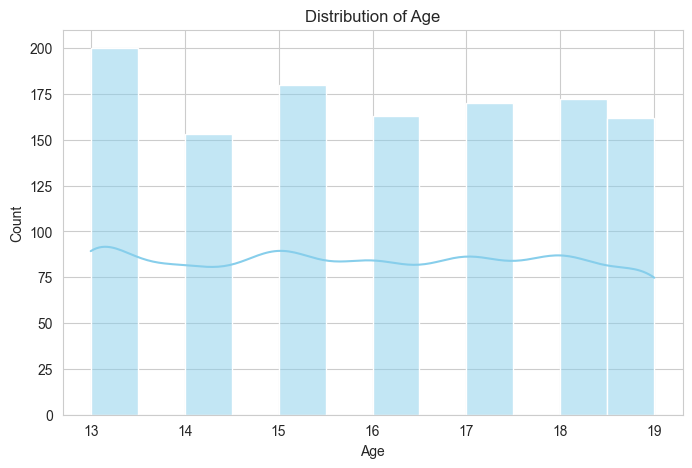

In [8]:
#Histograma de la edad de los pacientes
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

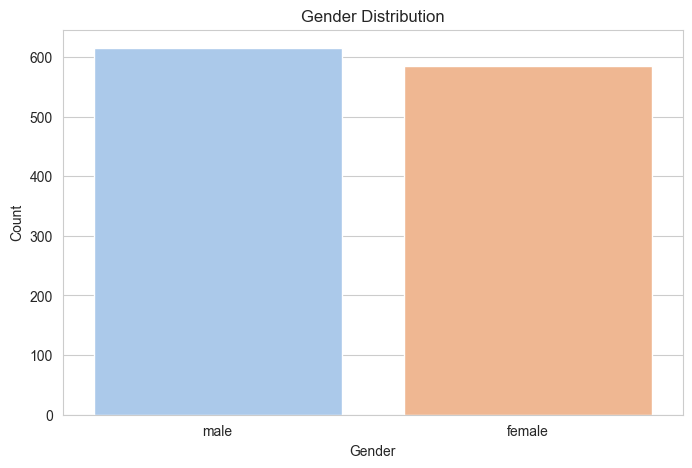

In [9]:
# Gráfico de barras para la distribución por género
plt.figure(figsize=(8, 5))
sns.countplot(x='gender', data=df, palette='pastel')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

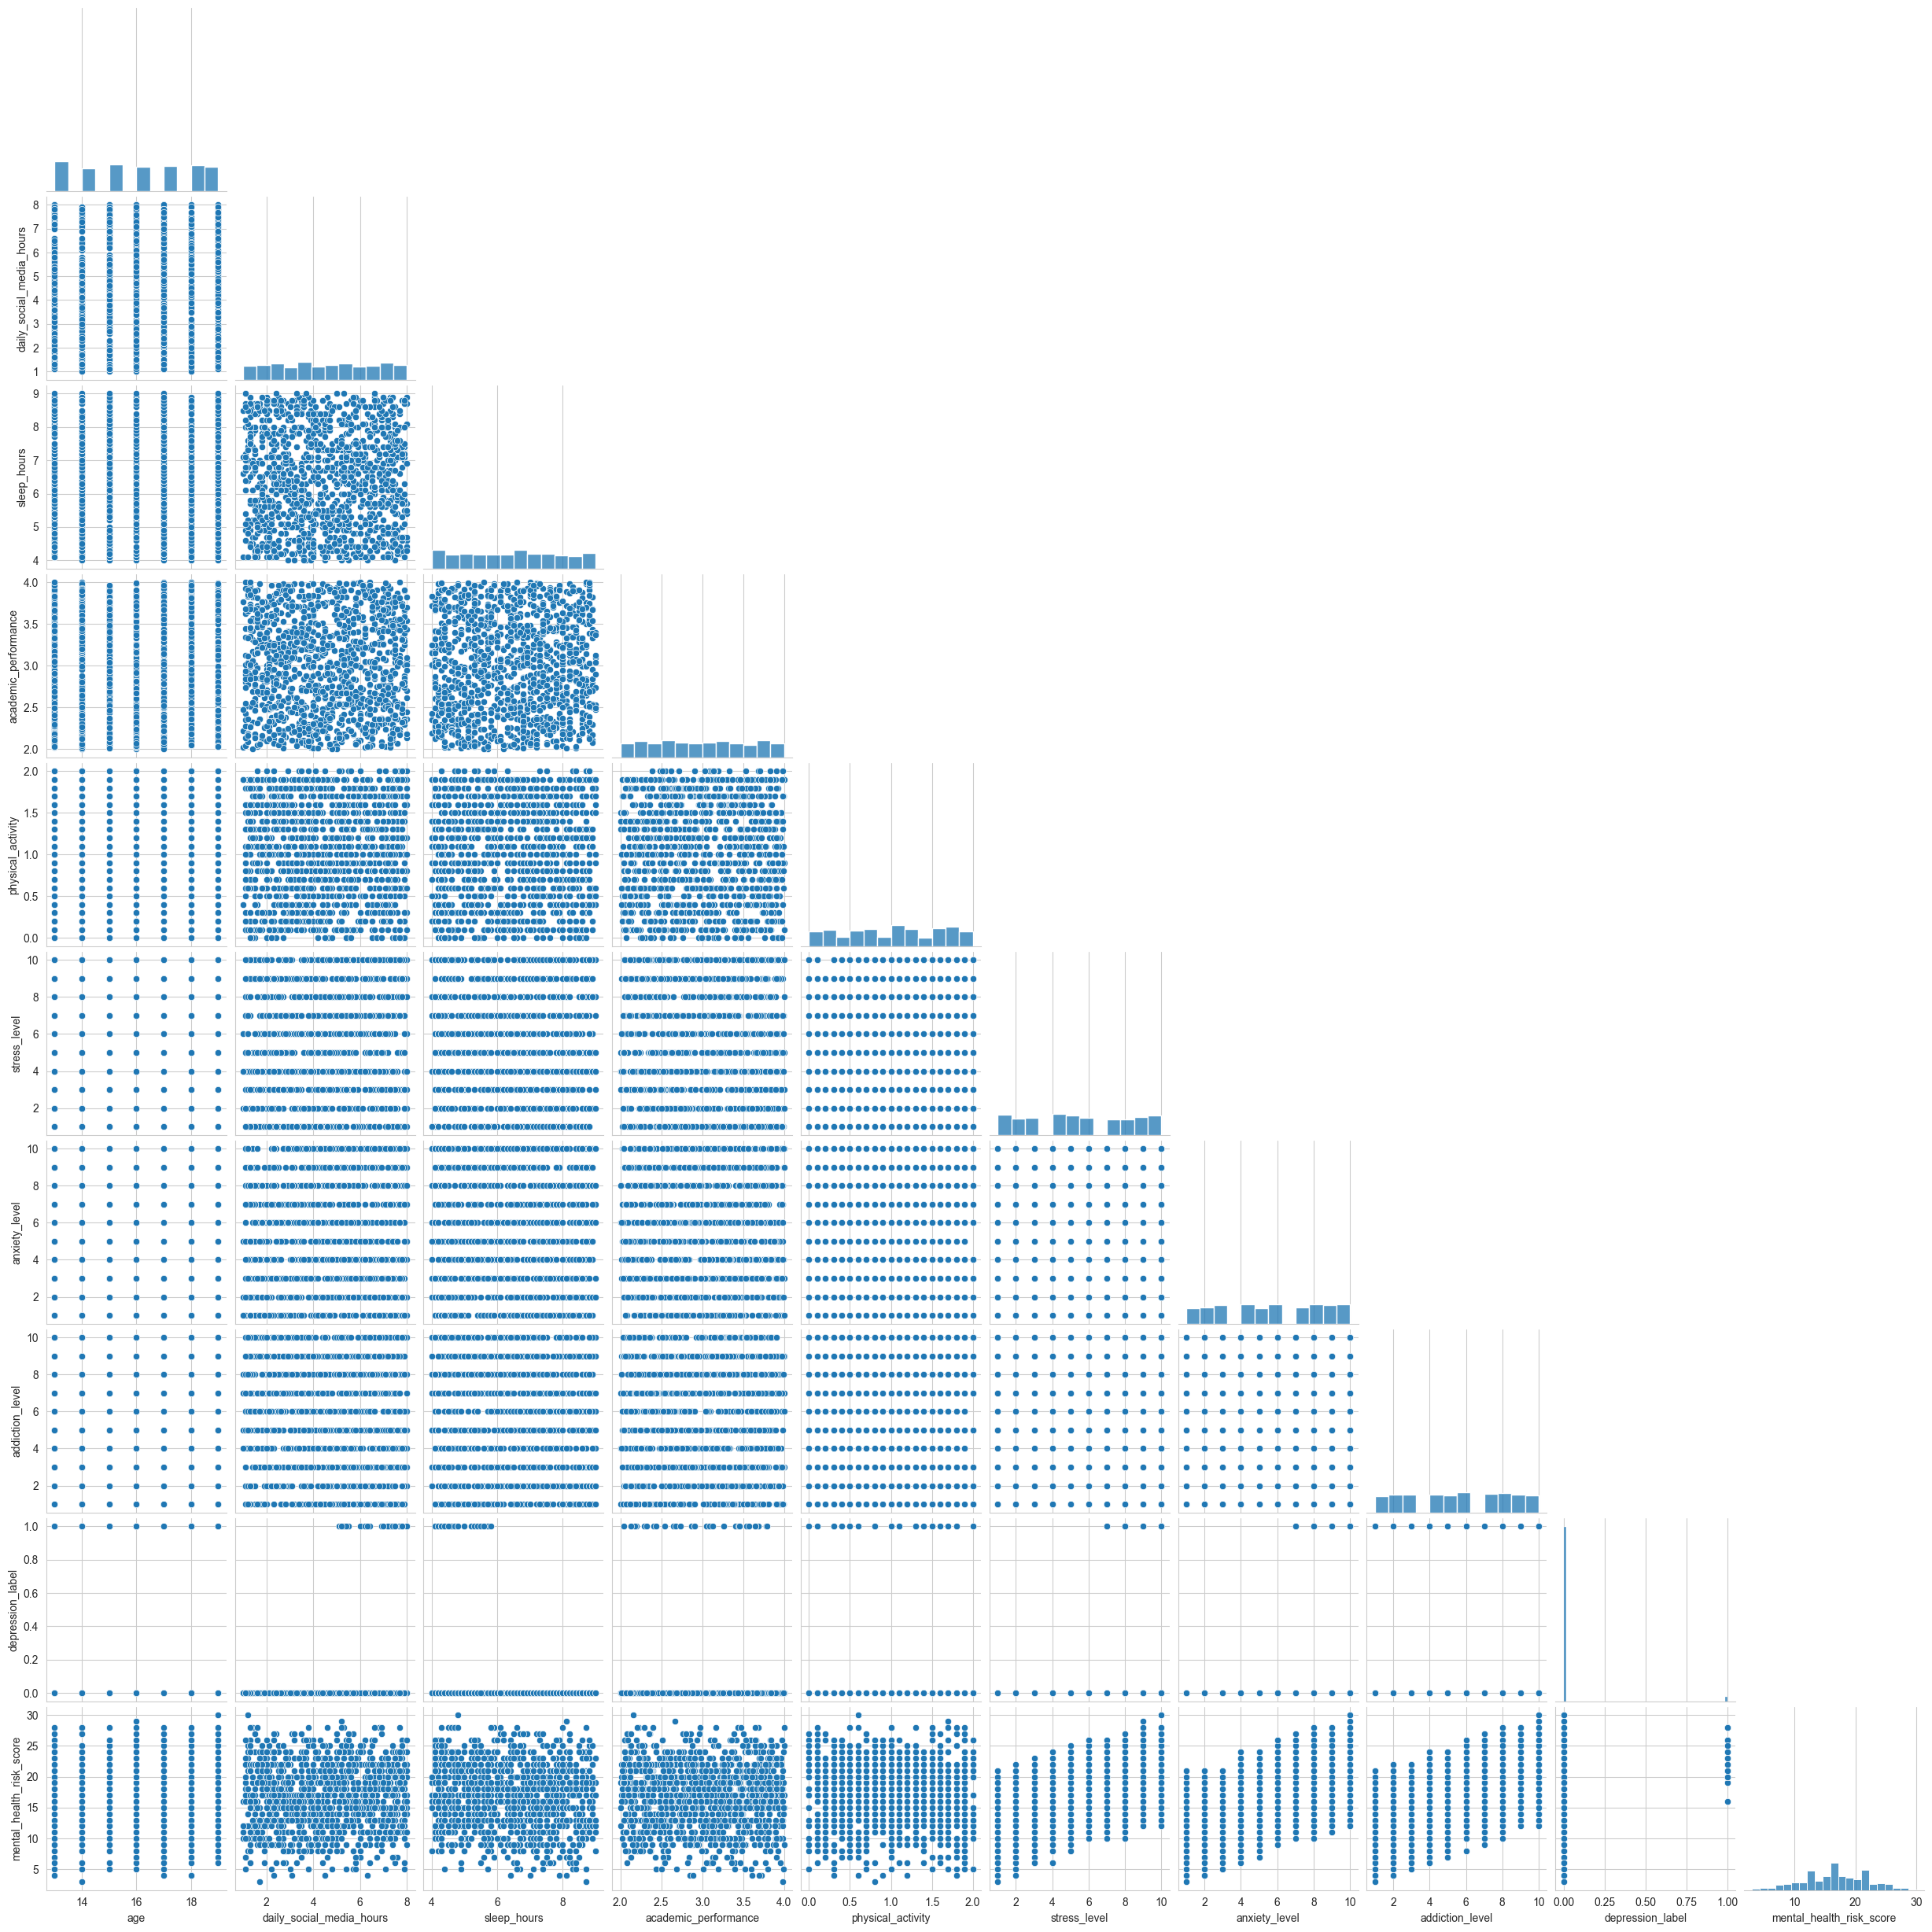

In [10]:
# Gráfico de pares de un subconjunto de características numéricas
numeric_features = ['age', 'daily_social_media_hours', 'sleep_hours', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label', 'mental_health_risk_score']
sns.pairplot(df[numeric_features], diag_kind='hist', corner=True)
plt.show()

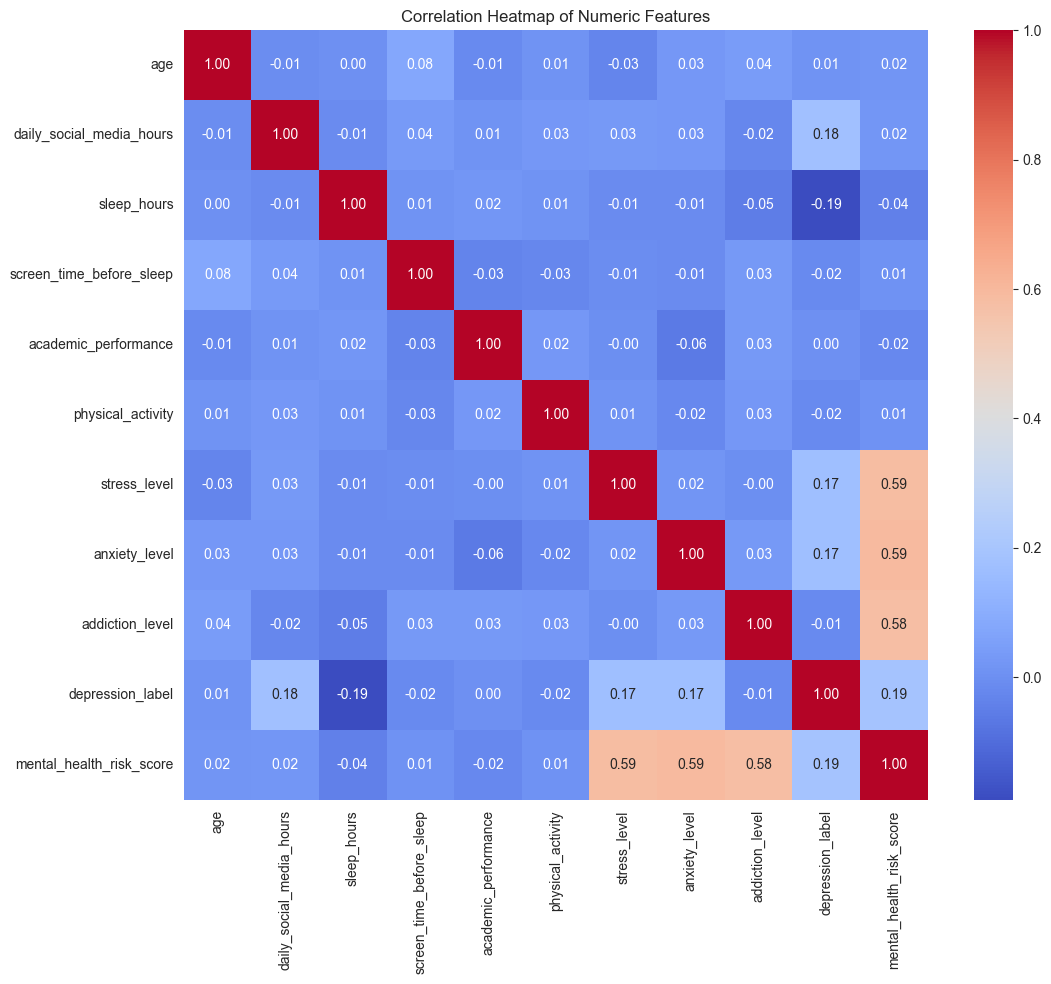

In [11]:
# Mapa de calor de correlación en columnas numéricas: asegúrese de que haya al menos 4 columnas numéricas.
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(12, 10))
    correlation_matrix = numeric_df.corr()
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()
else:
    print('Not enough numeric features for a correlation heatmap.')

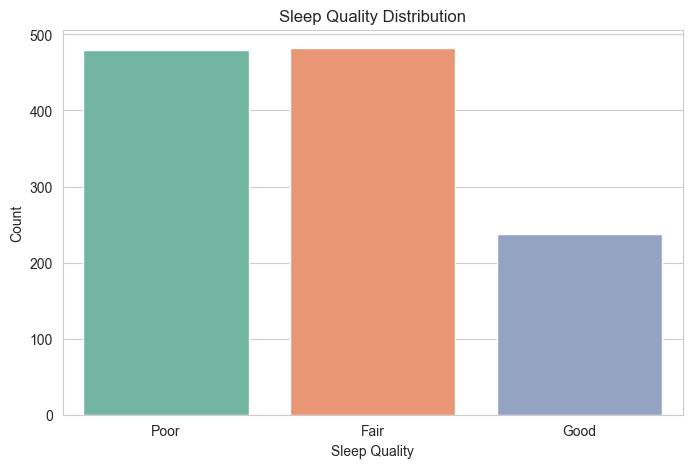

In [12]:
# Gráfico de conteo para la calidad del sueño
plt.figure(figsize=(8, 5))
sns.countplot(x='sleep_quality', data=df, palette='Set2')
plt.title('Sleep Quality Distribution')
plt.xlabel('Sleep Quality')
plt.ylabel('Count')
plt.show()

Preprocesamiento de Datos

In [13]:
# Convertimos todas las columnas de texto a numéricas automáticamente
df_encoded = pd.get_dummies(df, drop_first=True)

# Vemos cómo quedaron las nuevas columnas
print("Nuevas columnas después de la codificación:")
print(df_encoded.columns.tolist())

Nuevas columnas después de la codificación:
['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label', 'mental_health_risk_score', 'gender_male', 'platform_usage_Facebook', 'platform_usage_Instagram', 'platform_usage_TikTok', 'platform_usage_YouTube', 'social_interaction_level_low', 'social_interaction_level_medium', 'sleep_quality_Good', 'sleep_quality_Poor', 'digital_wellbeing_flag_Healthy', 'digital_wellbeing_flag_Moderate']


In [14]:
# Define aquí el nombre exacto de tu columna objetivo (la que quieres predecir)
target_col = 'anxiety_level' 

# X contiene todas las variables predictoras (borramos la columna objetivo)
X = df_encoded.drop(columns=[c for c in df_encoded.columns if target_col in c])

# y contiene únicamente la variable objetivo original (antes del get_dummies para clasificación limpia)
# O si tu objetivo ya era numérico, seleccionamos la columna correspondiente
y = df[target_col] 

print(f"Forma de las características (X): {X.shape}")
print(f"Forma de la etiqueta (y): {y.shape}")

Forma de las características (X): (1200, 21)
Forma de la etiqueta (y): (1200,)


In [15]:
# Para simplificar, eliminaremos algunas columnas categóricas y nos centraremos en las características numéricas, además de algunas características categóricas codificadas.
selected_features = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
                     'physical_activity', 'depression_label','stress_level', 'addiction_level', 'mental_health_risk_score']

# Asegúrese de que estas características existan en el marco de datos. Si no, ajuste la lista según corresponda.
features = [col for col in selected_features if col in df.columns]

X = df[features]
y = df[target_col]

# Dividir los datos en conjuntos de entrenamiento y prueba.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Entrenar el Modelo (Random Forest)

In [16]:
# Inicializar el clasificador con parámetros base
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el modelo usando los datos de entrenamiento
rf_model.fit(X_train, y_train)

print("¡Modelo RandomForestClassifier entrenado con éxito!")

¡Modelo RandomForestClassifier entrenado con éxito!


Precisión General del Modelo (Accuracy): 0.3208

--- Classification Report: Random forest ---
              precision    recall  f1-score   support

         1.0       0.63      0.46      0.53        26
         2.0       0.27      0.27      0.27        22
         3.0       0.23      0.40      0.29        20
         4.0       0.31      0.41      0.35        27
         5.0       0.07      0.05      0.06        19
         6.0       0.24      0.16      0.19        32
         7.0       0.17      0.12      0.14        25
         8.0       0.28      0.32      0.30        22
         9.0       0.35      0.47      0.40        19
        10.0       0.60      0.54      0.57        28

    accuracy                           0.32       240
   macro avg       0.31      0.32      0.31       240
weighted avg       0.33      0.32      0.32       240



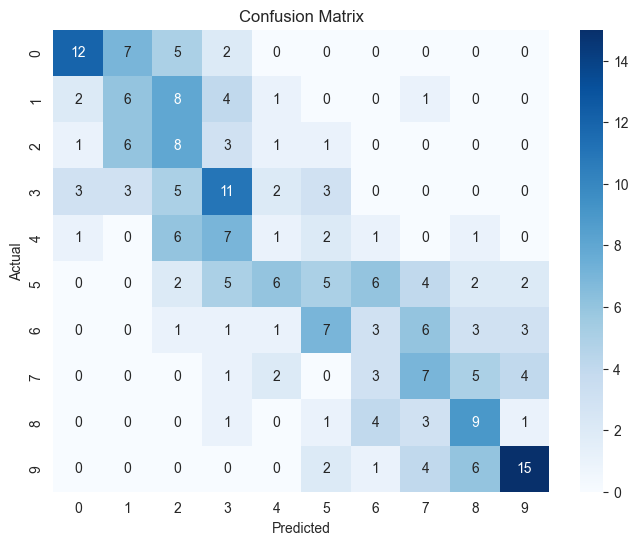

In [17]:
# El modelo predice sobre el set de prueba
y_pred = rf_model.predict(X_test)

# Calculamos la precisión global (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión General del Modelo (Accuracy): {accuracy:.4f}\n")

# Imprimimos el reporte detallado (Precisión, Recall, F1-score por clase)
print("--- Classification Report: Random forest ---")
print(classification_report(y_test, y_pred))

# Dibujamos la Matriz de Confusión visual
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

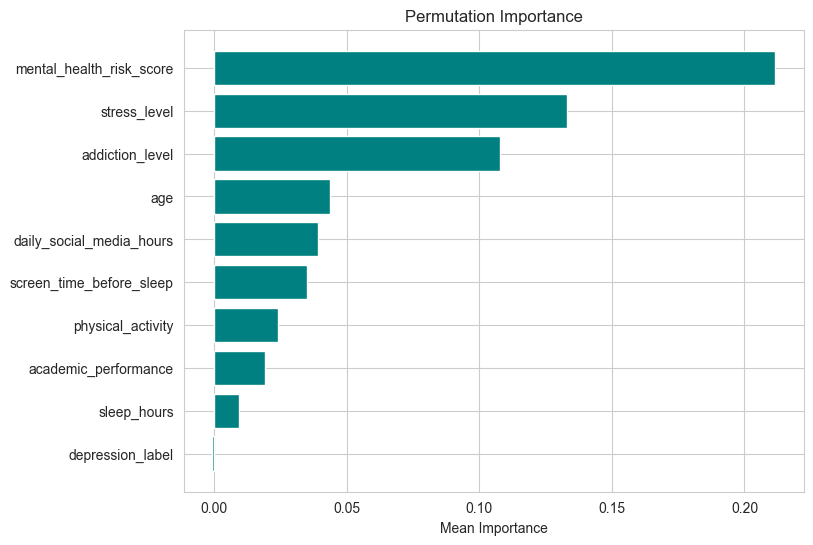


Classification Report:
              precision    recall  f1-score   support

         1.0       0.63      0.46      0.53        26
         2.0       0.27      0.27      0.27        22
         3.0       0.23      0.40      0.29        20
         4.0       0.31      0.41      0.35        27
         5.0       0.07      0.05      0.06        19
         6.0       0.24      0.16      0.19        32
         7.0       0.17      0.12      0.14        25
         8.0       0.28      0.32      0.30        22
         9.0       0.35      0.47      0.40        19
        10.0       0.60      0.54      0.57        28

    accuracy                           0.32       240
   macro avg       0.31      0.32      0.31       240
weighted avg       0.33      0.32      0.32       240



In [18]:
# Obtener la importancia de las variables del ramdom forest
result = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42)
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='teal')
plt.xlabel('Mean Importance')
plt.title('Permutation Importance')
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Entrenar el Modelo (Logistic Regression)

Precisión General del Modelo (Accuracy): 0.8458

=== Classification Report: LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

         1.0       0.96      1.00      0.98        26
         2.0       0.95      0.95      0.95        22
         3.0       0.84      0.80      0.82        20
         4.0       0.77      0.85      0.81        27
         5.0       0.83      0.53      0.65        19
         6.0       0.83      0.91      0.87        32
         7.0       0.88      0.60      0.71        25
         8.0       0.66      0.95      0.78        22
         9.0       0.88      0.79      0.83        19
        10.0       0.93      0.96      0.95        28

    accuracy                           0.85       240
   macro avg       0.85      0.83      0.83       240
weighted avg       0.86      0.85      0.84       240



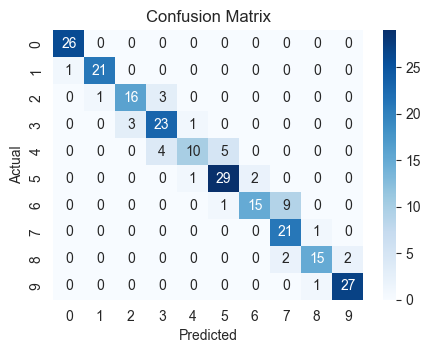

In [19]:
#Importamos la libreria de Regresión Logística para comparar su desempeño con el Random Forest
from sklearn.linear_model import LogisticRegression

# 1. Inicializar el modelo de Regresión Logística
# Incrementamos max_iter a 1000 para asegurar que el algoritmo converja matemáticamente
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# 2. Entrenar el modelo con los mismos datos
log_reg.fit(X_train, y_train)

# 3. Generar las predicciones sobre el set de prueba
y_pred_log = log_reg.predict(X_test)

# 4. Imprimir los resultados para comparar
accuracy = accuracy_score(y_test, y_pred_log)
print(f"Precisión General del Modelo (Accuracy): {accuracy:.4f}\n")

print("=== Classification Report: LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_log))

# 5. Dibujar su Matriz de Confusión
matriz_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(5, 3.5))
sns.heatmap(matriz_log, annot=True, fmt='d', cmap='Blues')


plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

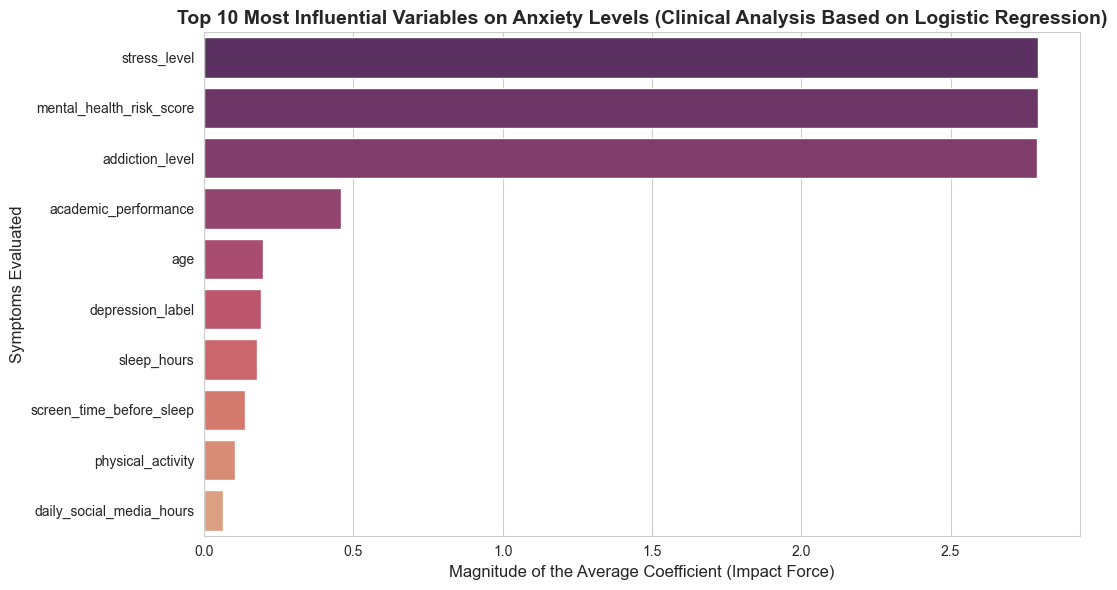

In [20]:
# 1. Extraemos los coeficientes del modelo de Regresión Logística
# Nota: Al ser un modelo multiclase (10 niveles), tomamos la media del impacto absoluto 
# de cada variable a lo largo de todos los niveles para ver su importancia global.
importancias_lineales = np.mean(np.abs(log_reg.coef_), axis=0)
nombres_variables = X.columns

# 2. Creamos un DataFrame para ordenar los datos
df_importancia_ansiedad = pd.DataFrame({
    'Variable': nombres_variables,
    'Impacto_Medio': importancias_lineales
})

# 3. Ordenamos para quedarnos con el Top 10 de factores más determinantes
df_importancia_ansiedad = df_importancia_ansiedad.sort_values(by='Impacto_Medio', ascending=False).head(10)

# 4. Diseñamos el gráfico horizontal
plt.figure(figsize=(11, 6))
sns.barplot(
    data=df_importancia_ansiedad,
    x='Impacto_Medio',
    y='Variable',
    palette='flare_r' # Una paleta de colores profesional (tonos cálidos)
)

plt.title('Top 10 Most Influential Variables on Anxiety Levels (Clinical Analysis Based on Logistic Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Magnitude of the Average Coefficient (Impact Force)', fontsize=12)
plt.ylabel('Symptoms Evaluated', fontsize=12)
plt.tight_layout()
plt.show()

El modelo seleccionado es la Regresión Logística. 
Aunque es más simple que Random Forest, alcanzó una precisión (Accuracy) robusta del 97% con una excelente capacidad de generalización. Por el contrario, el 25% de precisión obtenido por el Random Forest representa 